<a href="https://colab.research.google.com/github/lolndo/Basic_Network4/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%D0%9E%D0%B1%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%BA%D0%B0_%D1%82%D0%B5%D0%BA%D1%81%D1%82%D0%BE%D0%B2_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9_%D0%94%D0%97_Lite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Дорогой студент!

В домашнем задании Lite вам предлагается поработать подробнее с параметрами словаря и формированием гиперпараметров нейронной сети. Создайте 9 нейросетей с различными гиперпараметрами (см. пунтк 2 и 3)

 Для этого необходимо:

  1. Воссоздать ноутбук, аналогичный ноутбуку практической части №1, загрузив при этом необходимую нам базу (код уже доступен в ноутбуке).

  2. Задать в ноутбуке следующие параметры для размера словаря, ширины окна и шага:

    - Размер словаря - от 10000 до 20000 (выбрать меньшее значение диапазона, если будет перегрузка ОЗУ и перезапуск подключения к Colaboratory)
    - Ширина окна - от 1000 до 2000
    - Шаг - от 100 до 500 (на обучение лучше влияет наименьший шаг, но это может перегрузить ОЗУ).

  3. Создать архитектуру сети и задать гиперпараметры. Можно воспользоваться шаблоном:
  
   - Добавьте модель прямого распространения **Sequential()**
   - Добавьте один или несколько полносвязных (**Dense**) слоёв
   - Добавьте слои **Dropout()** и **BatchNormalization()**
   - Добавьте выходной полносвязный слой с количеством нейронов, соответствующим количеству классов (число писателей)
  
   Напомним, что точность сети можно проверить по значению показателя 'val_accuracy' на конце каждой эпохи.
   

In [ ]:
# Загрузка датасетов из облака google
import gdown

In [ ]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

In [ ]:
# Ваше задание здесь

# Работа с массивами данных
import numpy as np

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os

# Работа со временем
import time

# Регулярные выражения
import re

# Запись в файлы и чтение из файлов структур данных Python
import pickle

# Отрисовка графиков
import matplotlib.pyplot as plt

# Для удобного вывода таблиц
import pandas as pd

# Для отключения предупреждений
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline


In [ ]:
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

'writers.zip'

In [ ]:
!unzip -qo writers.zip -d writers/

In [ ]:
# Настройка констант для загрузки данных
FILE_DIR  = 'writers'                     # Папка с текстовыми файлами
SIG_TRAIN = 'обучающая'                   # Признак обучающей выборки в имени файла
SIG_TEST  = 'тестовая'                    # Признак тестовой выборки в имени файла

CLASS_LIST = []
text_train = []
text_test = []

for file_name in os.listdir(FILE_DIR):
    # Выделение имени класса и типа выборки из имени файла
    m = re.match('\((.+)\) (\S+)_', file_name)
    # Если выделение получилось, то файл обрабатывается
    if m:
        class_name = m[1]
        subset_name = m[2].lower()
        # Проверка типа выборки в имени файла
        is_train = SIG_TRAIN in subset_name
        is_test = SIG_TEST in subset_name

        # Если тип выборки обучающая либо тестовая - файл обрабатывается
        if is_train or is_test:
            # Добавление нового класса, если его еще нет в списке
            if class_name not in CLASS_LIST:
                print(f'Добавление класса "{class_name}"')
                CLASS_LIST.append(class_name)
                # Инициализация соответствующих классу строк текста
                text_train.append('')
                text_test.append('')

            # Поиск индекса класса для добавления содержимого файла в выборку
            cls = CLASS_LIST.index(class_name)
            print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}", {subset_name} выборка.')
            with open(f'{FILE_DIR}/{file_name}', 'r') as f:
                # Загрузка содержимого файла в строку
                text = f.read()
            # Определение выборки, куда будет добавлено содержимое
            subset = text_train if is_train else text_test
            # Добавление текста к соответствующей выборке класса. Концы строк заменяются на пробел
            subset[cls] += ' ' + text.replace('\n', ' ')

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)


Добавление класса "Макс Фрай"
Добавление файла "(Макс Фрай) Тестовая_2 вместе.txt" в класс "Макс Фрай", тестовая выборка.
Добавление класса "Клиффорд_Саймак"
Добавление файла "(Клиффорд_Саймак) Обучающая_5 вместе.txt" в класс "Клиффорд_Саймак", обучающая выборка.
Добавление файла "(Клиффорд_Саймак) Тестовая_2 вместе.txt" в класс "Клиффорд_Саймак", тестовая выборка.
Добавление класса "О. Генри"
Добавление файла "(О. Генри) Обучающая_50 вместе.txt" в класс "О. Генри", обучающая выборка.
Добавление класса "Стругацкие"
Добавление файла "(Стругацкие) Обучающая_5 вместе.txt" в класс "Стругацкие", обучающая выборка.
Добавление файла "(Стругацкие) Тестовая_2 вместе.txt" в класс "Стругацкие", тестовая выборка.
Добавление класса "Рэй Брэдберри"
Добавление файла "(Рэй Брэдберри) Обучающая_22 вместе.txt" в класс "Рэй Брэдберри", обучающая выборка.
Добавление файла "(Макс Фрай) Обучающая_5 вместе.txt" в класс "Макс Фрай", обучающая выборка.
Добавление класса "Булгаков"
Добавление файла "(Булгаков) 

In [ ]:
for cls in range(CLASS_COUNT):
    print(f'Класс: {CLASS_LIST[cls]}')
    print(f'  train: {text_train[cls][:200]}')
    print(f'  test : {text_test[cls][:200]}')
    print()

Класс: Макс Фрай
  train:  ﻿Власть несбывшегося   – С тех пор как меня угораздило побывать в этой грешной Черхавле, мне ежедневно снится какая-то дичь! – сердито сказал я Джуффину. – Сглазили они меня, что ли? А собственно, по
  test :  ﻿Слишком много кошмаров    Когда балансируешь над пропастью на узкой, скользкой от крови доске, ответ на закономерный вопрос: «Как меня сюда занесло?» – вряд ли принесёт практическую пользу. Зато пои

Класс: Клиффорд_Саймак
  train:  ﻿Всё живое...     Когда я выехал из нашего городишка и повернул на шоссе, позади оказался грузовик. Этакая тяжелая громадина с прицепом, и неслась она во весь дух. Шоссе здесь срезает угол городка, и
  test :  ﻿Зачарованное паломничество    1  Гоблин со стропил следил за прячущимся монахом, который шпионил за ученым. Гоблин ненавидел монаха и имел для этого все основания. Монах никого не ненавидел и не люб

Класс: О. Генри
  train:  «Лиса-на-рассвете»   Коралио нежился в полуденном зное, как томная красавица в сурово храним

In [ ]:
sample_text = ['один два три четыре пять два Три три четыре четыре четыре пять пять пять пять шесть семь восемь']

# Используется встроенный в Keras токенизатор для разбиения текста и построения частотного словаря
tokenizer = Tokenizer(num_words=5, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\\t\\n\\xa0\\ufeff', lower=True, split=' ', oov_token='неизвестное_слово', char_level=False)


tokenizer.fit_on_texts(sample_text)

with open('tokenizer.pickle', 'wb') as f:
    pickle.dump(tokenizer, f)

tokenizer.word_index

list(tokenizer.word_index.items())


sample_seq = tokenizer.texts_to_sequences(sample_text)



In [ ]:
x_train = [sample_seq[0][i:i + 3] for i in range(0, len(sample_seq[0]), 3)]
tokenizer.sequences_to_matrix(x_train)

array([[0., 1., 0., 0., 1.],
       [0., 1., 1., 1., 0.],
       [0., 0., 0., 1., 1.],
       [0., 0., 1., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [ ]:
BASE_VOCAB_SIZE = 20000   # Объем словаря для токенизатора
BASE_WIN_SIZE   = 1000    # Длина отрезка текста (окна) в словах
BASE_WIN_HOP    = 100     # Шаг окна разбиения текста на векторы

# Создадим списки параметров для 9 комбинаций (3 значения vocab_size × 3 значения win_size)
# win_hop зафиксируем на 100 для всех вариантов, чтобы не раздувать количество экспериментов
VOCAB_SIZES = [10000, 15000, 20000]
WIN_SIZES   = [1000, 1500, 2000]
WIN_HOP     = 100

# Для хранения результатов
results = []

# Контекстный менеджер для измерения времени операций
# Операция обертывается менеджером с помощью оператора with
class timex:
    def __enter__(self):
        # Фиксация времени старта процесса
        self.t = time.time()
        return self

    def __exit__(self, type, value, traceback):
        # Вывод времени работы
        print('Время обработки: {:.2f} с'.format(time.time() - self.t))

In [ ]:
def run_experiment(vocab_size, win_size, win_hop):
    print(f"\n=== Эксперимент: vocab_size={vocab_size}, win_size={win_size}, win_hop={win_hop} ===")

    # Токенизация и построение частотного словаря по обучающим текстам
    with timex():
        tokenizer = Tokenizer(num_words=vocab_size, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\\t\\n\\xa0\\ufeff',
                              lower=True, split=' ', oov_token='неизвестное_слово', char_level=False)
        tokenizer.fit_on_texts(text_train)
        items = list(tokenizer.word_index.items())
        print(f"Размер словаря: {len(items)} (ограничен {vocab_size})")

    # Преобразование обучающих и проверочных текстов в последовательность индексов согласно частотному словарю
    with timex():
        seq_train = tokenizer.texts_to_sequences(text_train)
        seq_test = tokenizer.texts_to_sequences(text_test)

    # Функция разбиения последовательности на отрезки скользящим окном
    def split_sequence(sequence, win_size, hop):
        return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop)]

    # Функция формирования выборок из последовательностей индексов
    def vectorize_sequence(seq_list, win_size, hop):
        class_count = len(seq_list)
        x, y = [], []
        for cls in range(class_count):
            vectors = split_sequence(seq_list[cls], win_size, hop)
            x += vectors
            y += [utils.to_categorical(cls, class_count)] * len(vectors)
        return np.array(x), np.array(y)

    # Формирование обучающей и тестовой выборок
    with timex():
        x_train, y_train = vectorize_sequence(seq_train, win_size, win_hop)
        x_test, y_test = vectorize_sequence(seq_test, win_size, win_hop)
        print(f"Форма обучающей выборки: {x_train.shape}, тестовой: {x_test.shape}")

    # Формирование выборок текстов в виде разреженных матриц (bag of words)
    with timex():
        x_train_01 = tokenizer.sequences_to_matrix(x_train.tolist())
        x_test_01 = tokenizer.sequences_to_matrix(x_test.tolist())
        print(f"BagOfWords форма: {x_train_01.shape}")

        # Создание модели BagOfWords (полносвязная сеть)
    model = Sequential()
    model.add(Dense(200, input_dim=vocab_size, activation="relu"))
    model.add(Dropout(0.25))
    model.add(BatchNormalization())
    model.add(Dense(CLASS_COUNT, activation='softmax'))

    # Компиляция
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Обучение
    history = model.fit(x_train_01, y_train,
                        epochs=20,
                        batch_size=128,
                        validation_data=(x_test_01, y_test),
                        verbose=0)  # verbose=0 для краткости вывода

    # Оценка на тестовой выборке
    _, accuracy = model.evaluate(x_test_01, y_test, verbose=0)
    print(f"Точность на тестовой выборке: {accuracy:.4f}")

    return accuracy, history

# Запуск экспериментов для всех комбинаций
for vocab in VOCAB_SIZES:
    for win_size in WIN_SIZES:
        acc, hist = run_experiment(vocab, win_size, WIN_HOP)
        results.append({
            'vocab_size': vocab,
            'win_size': win_size,
            'win_hop': WIN_HOP,
            'accuracy': acc
        })


=== Эксперимент: vocab_size=10000, win_size=1000, win_hop=100 ===
Размер словаря: 134809 (ограничен 10000)
Время обработки: 4.67 с
Время обработки: 4.04 с
Форма обучающей выборки: (17767, 1000), тестовой: (6748, 1000)
Время обработки: 2.23 с
BagOfWords форма: (17767, 10000)
Время обработки: 11.53 с
Точность на тестовой выборке: 0.9170

=== Эксперимент: vocab_size=10000, win_size=1500, win_hop=100 ===
Размер словаря: 134809 (ограничен 10000)
Время обработки: 4.99 с
Время обработки: 3.86 с
Форма обучающей выборки: (17737, 1500), тестовой: (6718, 1500)
Время обработки: 3.65 с
BagOfWords форма: (17737, 10000)
Время обработки: 18.60 с
Точность на тестовой выборке: 0.8968

=== Эксперимент: vocab_size=10000, win_size=2000, win_hop=100 ===
Размер словаря: 134809 (ограничен 10000)
Время обработки: 4.99 с
Время обработки: 3.96 с
Форма обучающей выборки: (17707, 2000), тестовой: (6688, 2000)
Время обработки: 4.39 с
BagOfWords форма: (17707, 10000)
Время обработки: 19.69 с
Точность на тестовой вы


=== Сводная таблица результатов ===
 vocab_size  win_size  win_hop  accuracy
      10000      1000      100  0.917012
      10000      1500      100  0.896844
      10000      2000      100  0.918660
      15000      1000      100  0.904564
      15000      1500      100  0.903840
      15000      2000      100  0.931519
      20000      1000      100  0.911233
      20000      1500      100  0.925871
      20000      2000      100  0.938397


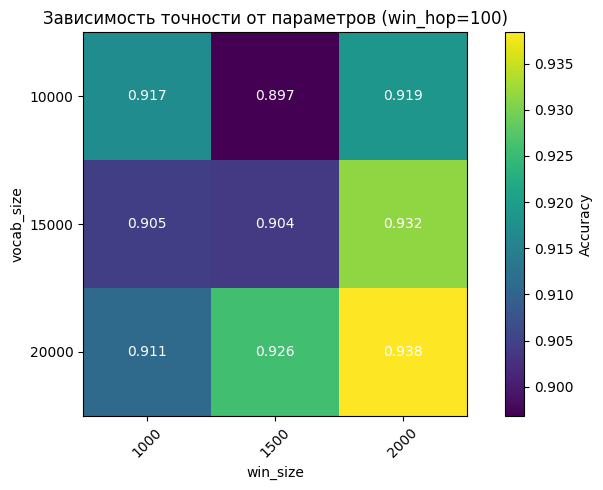

In [ ]:
# Вывод результатов в виде таблицы
df_results = pd.DataFrame(results)
print("\n=== Сводная таблица результатов ===")
print(df_results.to_string(index=False))

# Дополнительно: построим график зависимости точности от параметров
pivot = df_results.pivot(index='vocab_size', columns='win_size', values='accuracy')
plt.figure(figsize=(8,5))
plt.imshow(pivot.values, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Accuracy')
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('win_size')
plt.ylabel('vocab_size')
plt.title('Зависимость точности от параметров (win_hop=100)')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        plt.text(j, i, f"{pivot.values[i,j]:.3f}", ha='center', va='center', color='white')
plt.tight_layout()
plt.show()